# Análisis exploratorio de Datos

Natalia Alvarado, Camilo Mujica, Sergio Rada, Carlos Romero

# Introducción y Contexto
En el entorno altamente competitivo de las telecomunicaciones, la retención de clientes se ha convertido en un factor estratégico clave para la sostenibilidad y rentabilidad de las empresas. Adquirir nuevos clientes suele implicar costos significativamente mayores que conservar los existentes, lo que hace que la identificación temprana de clientes propensos a abandonar el servicio (customer churn) sea una prioridad crítica.

Las empresas de telecomunicaciones enfrentan tasas significativas de pérdida de clientes. La predicción temprana de churn permite intervenir de manera oportuna. A través de modelos supervisados e interpretables, se puede identificar el perfil de clientes con mayor probabilidad de abandono y tomar decisiones informadas.

En este proyecto se trabaja con el dataset Telco Customer Churn, proveniente de los conjuntos de datos de muestra de IBM, cuyo objetivo principal es predecir el comportamiento de los clientes para implementar estrategias efectivas de retención. Este problema se enmarca dentro de una tarea de clasificación supervisada, donde se busca determinar si un cliente abandonará o no la compañía, basándose en sus características y comportamiento histórico.

# Objetivo 
Construir modelos precisos de clasificación utilizando algoritmos como Random Forest, XGBoost, CatBoost y LightGBM, integrados en un flujo de trabajo con Pipeline, ajuste de hiperparámetros mediante GridSearchCV, visualización de importancia de variables y uso de LIME para explicabilidad. Además, se solicita diseñar una arquitectura básica de MLOps para implementar el modelo en un entorno de producción.

# Descripción del dataset
El conjunto de datos está estructurado a nivel de cliente, donde cada fila representa un cliente individual y cada columna describe un atributo específico relacionado con su perfil, servicios contratados y comportamiento.

La variable objetivo del análisis es 'Churn', que indica si el cliente abandonó el servicio en el último mes (Yes/No).

- **Fuente:** https://www.kaggle.com/blastchar/telco-customer-churn

# Carga del dataset

In [2]:
#Carga de librerias  
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, f1_score, make_scorer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier



#Carga de datos  
df = pd.read_csv("../data/telco_churn.csv")

Una vez cargado, analicemos la información básica del dataset:

In [87]:
#Información básica del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [88]:
#dimensiones
df.shape

(7043, 21)

Se cuenta con una cantidad de 7043 observaciones, cada observación representando a un cliente, caracterizadas por 21 variables, 3 Númericas y 18 categóricas, que describen los atributos de dicho cliente. Procedamos a construir un diccionario que contenga las variables:

## Diccionario de Variables 

| Variable            | Tipo de Dato | Descripción |
|--------------------|-------------|------------|
| customerID         | object      | Identificador único del cliente. |
| gender             | object      | Género del cliente (Male / Female). |
| SeniorCitizen      | int64       | Indica si el cliente es adulto mayor (1 = Sí, 0 = No). |
| Partner            | object      | Indica si el cliente tiene pareja (Yes / No). |
| Dependents         | object      | Indica si el cliente tiene dependientes (Yes / No). |
| tenure             | int64       | Número de meses que el cliente ha permanecido con la compañía. |
| PhoneService       | object      | Indica si el cliente tiene servicio telefónico (Yes / No). |
| MultipleLines      | object      | Indica si el cliente tiene múltiples líneas telefónicas (Yes / No / No phone service). |
| InternetService    | object      | Tipo de servicio de internet contratado (DSL / Fiber optic / No). |
| OnlineSecurity     | object      | Indica si el cliente tiene servicio de seguridad en línea (Yes / No / No internet service). |
| OnlineBackup       | object      | Indica si el cliente tiene servicio de respaldo en línea (Yes / No / No internet service). |
| DeviceProtection   | object      | Indica si el cliente tiene protección de dispositivos (Yes / No / No internet service). |
| TechSupport        | object      | Indica si el cliente tiene soporte técnico (Yes / No / No internet service). |
| StreamingTV        | object      | Indica si el cliente tiene servicio de streaming de TV (Yes / No / No internet service). |
| StreamingMovies    | object      | Indica si el cliente tiene servicio de streaming de películas (Yes / No / No internet service). |
| Contract           | object      | Tipo de contrato del cliente (Month-to-month / One year / Two year). |
| PaperlessBilling   | object      | Indica si el cliente utiliza facturación electrónica (Yes / No). |
| PaymentMethod      | object      | Método de pago del cliente (Electronic check, Mailed check, Bank transfer, Credit card). |
| MonthlyCharges     | float64     | Cargos mensuales del cliente. |
| TotalCharges       | object      | Cargos totales acumulados por el cliente (puede requerir conversión a numérico). |
| Churn              | object      | Variable objetivo: indica si el cliente abandonó la compañía (Yes / No). |

Se visualizaran las primeras 10 filas del dataset para familiarizarse con su estructura:

In [89]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Aparte de esto, se puede ver que ninguna columna posee valores faltantes, se corroborara con la siguiente línea de código:

In [90]:
#Valores Faltantes
missing = df.isna().sum().to_frame("NaN")
missing["Porcentaje"] = (missing["NaN"] / len(df)) * 100
missing

,NaN,Porcentaje
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Nótese que no existen valores nulos en el dataset.  

## Análisis univariado  

A continuación se procederá a examinar cada variable de forma individual con el objetivo de entender su distribución, medidas centrales y de dispersión. Para complementar el análisis utilizaremos tablas estadísticas y gráficas según se considere adecuado.   

### Variables Categóricas  

Para esta sección se presentarán las tablas de frecuencia de cada variable categórica sin descripción. La variable 'customerID' es un identificador que no aporta información valiosa, por tanto será omitido en el análisis. Se comenzará por la variable objetivo: 

#### Churn

In [91]:
tabla = (
    df['Churn']
    .value_counts()
    .rename_axis('Churn')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,Churn,conteo,Porcentaje
0,No,5174,73.5
1,Yes,1869,26.5


#### Gender

In [92]:
tabla = (
    df['gender']
    .value_counts()
    .rename_axis('Gender')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,Gender,conteo,Porcentaje
0,Male,3555,50.5
1,Female,3488,49.5


#### Partner

In [93]:
tabla = (
    df['Partner']
    .value_counts()
    .rename_axis('Partner')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,Partner,conteo,Porcentaje
0,No,3641,51.7
1,Yes,3402,48.3


#### Dependents

In [94]:
tabla = (
    df['Dependents']
    .value_counts()
    .rename_axis('Dependents')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,Dependents,conteo,Porcentaje
0,No,4933,70.0
1,Yes,2110,30.0


#### PhoneService

In [95]:
tabla = (
    df['PhoneService']
    .value_counts()
    .rename_axis('PhoneService')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,PhoneService,conteo,Porcentaje
0,Yes,6361,90.3
1,No,682,9.7


#### MultipleLines

In [96]:
tabla = (
    df['MultipleLines']
    .value_counts()
    .rename_axis('MultipleLines')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,MultipleLines,conteo,Porcentaje
0,No,3390,48.1
1,Yes,2971,42.2
2,No phone service,682,9.7


#### InternetService

In [97]:
tabla = (
    df['InternetService']
    .value_counts()
    .rename_axis('InternetService')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,InternetService,conteo,Porcentaje
0,Fiber optic,3096,44.0
1,DSL,2421,34.4
2,No,1526,21.7


#### OnlineSecurity

In [98]:
tabla = (
    df['OnlineSecurity']
    .value_counts()
    .rename_axis('OnlineSecurity')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,OnlineSecurity,conteo,Porcentaje
0,No,3498,49.7
1,Yes,2019,28.7
2,No internet service,1526,21.7


#### OnlineBackup

In [99]:
tabla = (
    df['OnlineBackup']
    .value_counts()
    .rename_axis('OnlineBackup')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,OnlineBackup,conteo,Porcentaje
0,No,3088,43.8
1,Yes,2429,34.5
2,No internet service,1526,21.7


#### DeviceProtection

In [100]:
tabla = (
    df['DeviceProtection']
    .value_counts()
    .rename_axis('DeviceProtection')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,DeviceProtection,conteo,Porcentaje
0,No,3095,43.9
1,Yes,2422,34.4
2,No internet service,1526,21.7


#### TechSupport

In [101]:
tabla = (
    df['TechSupport']
    .value_counts()
    .rename_axis('TechSupport')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,TechSupport,conteo,Porcentaje
0,No,3473,49.3
1,Yes,2044,29.0
2,No internet service,1526,21.7


#### StreamingTV

In [102]:
tabla = (
    df['StreamingTV']
    .value_counts()
    .rename_axis('StreamingTV')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,StreamingTV,conteo,Porcentaje
0,No,2810,39.9
1,Yes,2707,38.4
2,No internet service,1526,21.7


#### StreamingMovies

In [103]:
tabla = (
    df['StreamingMovies']
    .value_counts()
    .rename_axis('StreamingMovies')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,StreamingMovies,conteo,Porcentaje
0,No,2785,39.5
1,Yes,2732,38.8
2,No internet service,1526,21.7


#### Contract

In [104]:
tabla = (
    df['Contract']
    .value_counts()
    .rename_axis('Contract')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,Contract,conteo,Porcentaje
0,Month-to-month,3875,55.0
1,Two year,1695,24.1
2,One year,1473,20.9


#### PaperlessBilling

In [105]:
tabla = (
    df['PaperlessBilling']
    .value_counts()
    .rename_axis('PaperlessBilling')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,PaperlessBilling,conteo,Porcentaje
0,Yes,4171,59.2
1,No,2872,40.8


#### PaymentMethod

In [106]:
tabla = (
    df['PaymentMethod']
    .value_counts()
    .rename_axis('PaymentMethod')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,PaymentMethod,conteo,Porcentaje
0,Electronic check,2365,33.6
1,Mailed check,1612,22.9
2,Bank transfer (automatic),1544,21.9
3,Credit card (automatic),1522,21.6


#### TotalCharges

In [107]:
tabla = (
    df['TotalCharges']
    .value_counts()
    .rename_axis('TotalCharges')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,TotalCharges,conteo,Porcentaje
0,20.2,11,0.2
1,,11,0.2
2,19.75,9,0.1
3,19.65,8,0.1
4,19.9,8,0.1
...,...,...,...
6526,1990.5,1,0.0
6527,7362.9,1,0.0
6528,346.45,1,0.0
6529,306.6,1,0.0


Para el caso de la variable 'TotalCharges' es necesario transformarla a una variable númerica para analizar su comportamiento:

In [108]:
#Convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.1 KB


Una vez realizada la transformación se puede notar que existen 11 valores faltantes, equivalentes a observaciones cuyo valor en 'TotalCharges' era " " que representaban que el cliente era nuevo y no poseía ningún cargo acumulado, por tanto esos valores faltantes serán imputados con el número 0 correspondiente:

In [109]:
#Se rellenan los NaN con 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.1 KB


Ya no se encuentran valores faltantes, una vez realizado esto se puede proceder al análisis de las variables númericas incluyendo a la que se acaba de transformar.

### Variables Númericas

Se cuentan con 4 variables númericas, para cada variable númerica se realizará una descripción, un histograma y un boxplot para analizar su comportamiento, sin embargo, no se hará esto con la variable 'SeniorCitizen' ya que es una variable númerica binaria y no tiene sentido analizarla de esa manera. Para solucionar esto se analizará 'SeniorCitizen' como una variable categórica, recordando que el valor 1 representa que es un ciudadano mayor, y el 0 el caso contrario:

#### Senior Citizen


In [110]:
tabla = (
    df['SeniorCitizen']
    .value_counts()
    .rename_axis('SeniorCitizen')
    .reset_index(name='conteo')
)

tabla['Porcentaje'] = (tabla['conteo'] / tabla['conteo'].sum() * 100).round(1)
tabla

,SeniorCitizen,conteo,Porcentaje
0,0,5901,83.8
1,1,1142,16.2


Aproximadamente el 84% de los clientes no son ciudadanos mayores.

Luego se realiza el análisis de las siguientes variables:

In [111]:
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
vars_to_remove = ["SeniorCitizen"]
num_vars = [v for v in num_vars if v not in vars_to_remove]

def plot_boxplots(df, num_vars):
    n = len(num_vars)
    cols = 3
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(5*cols, 4*rows))
    
    for i, col in enumerate(num_vars, 1):
        plt.subplot(rows, cols, i)
        sns.boxplot(x=df[col], color="#2ecc71") # Color verde suave
        plt.title(f"Boxplot de {col}", fontsize=12, fontweight='bold')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_histograms(df, num_vars, bins=30):
    n = len(num_vars)
    cols = 3 
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(5*cols, 4*rows))
    
    for i, col in enumerate(num_vars, 1):
        plt.subplot(rows, cols, i)
        # Agregamos KDE (línea de densidad) para ver mejor la distribución
        sns.histplot(df[col].dropna(), bins=bins, kde=True, color="#3498db") 
        plt.title(f"Histograma de {col}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def describe_variables(df, num_vars):
    desc = df[num_vars].describe().T
    desc["median"] = df[num_vars].median()
    desc["missing"] = df[num_vars].isna().sum()
    cols_order = ['count', 'mean', 'std', 'min', '25%', '50%', 'median', '75%', 'max', 'missing']
    return desc[cols_order]

resumen = describe_variables(df, num_vars)
print("Resumen Estadístico:")
display(resumen) 

Resumen Estadístico:


,count,mean,std,min,25%,50%,median,75%,max,missing
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,29.00,55.00,72.00,0
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,70.35,89.85,118.75,0
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,1394.55,3786.60,8684.80,0


El análisis de las variables numéricas muestra patrones interesantes sobre el comportamiento de los clientes. La variable tenure presenta una media de aproximadamente 32 meses, con una desviación estándar alta (≈24.5), lo que indica una gran dispersión en la antigüedad de los clientes; además, el hecho de que el mínimo sea 0 sugiere la presencia de clientes muy recientes, mientras que el máximo de 72 meses refleja clientes altamente fidelizados. Por otro lado, MonthlyCharges también exhibe variabilidad considerable, con valores que van desde 18.25 hasta 118.75, lo que evidencia la existencia de distintos niveles de servicios contratados; la mediana (70.35) superior al primer cuartil sugiere cierta concentración en planes de costo medio-alto. Finalmente, TotalCharges presenta la mayor dispersión (std ≈ 2266), lo cual es consistente con su naturaleza acumulativa y su dependencia tanto de la antigüedad como del cargo mensual; la diferencia notable entre la mediana (≈1394.55) y el máximo (≈8684.80) sugiere una distribución sesgada hacia la derecha, con clientes que han acumulado cargos significativamente altos a lo largo del tiempo. En conjunto, estas variables reflejan heterogeneidad en el comportamiento de los clientes, lo cual resulta clave para modelos predictivos de churn.


Generando Boxplots...


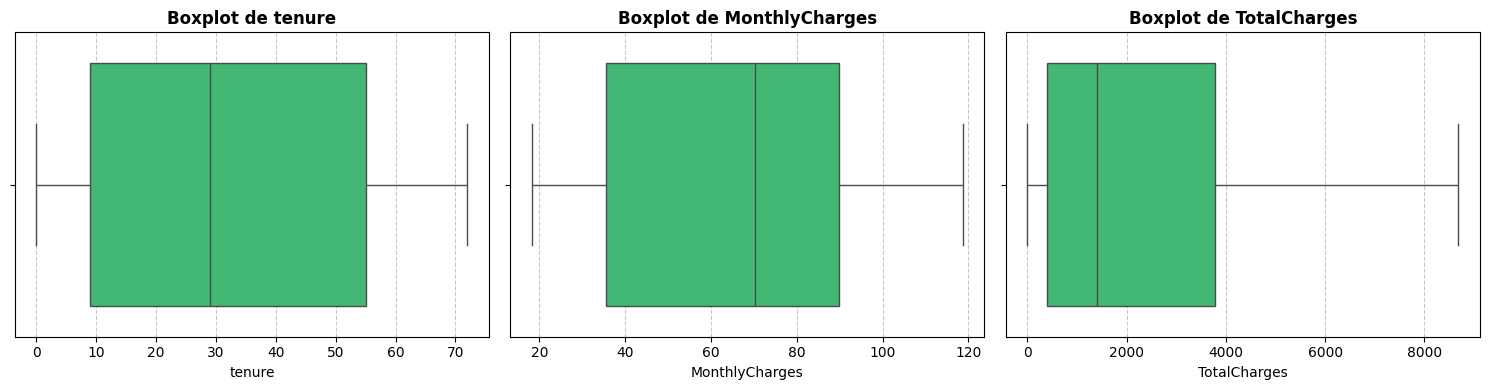

In [112]:
print("\nGenerando Boxplots...")
plot_boxplots(df, num_vars)

Los boxplots permiten observar la dispersión y posibles valores atípicos en las variables numéricas. En tenure, se aprecia una distribución relativamente amplia, con la mediana ubicada hacia valores bajos-medios y sin presencia marcada de outliers, lo que sugiere una distribución bastante equilibrada dentro de su rango (0 a 72 meses). En MonthlyCharges, la mediana se encuentra ligeramente desplazada hacia valores altos y el rango intercuartílico es amplio, lo que indica heterogeneidad en los planes contratados; tampoco se observan outliers extremos, lo que sugiere una distribución controlada. Por su parte, TotalCharges muestra una clara asimetría positiva: la mediana está cerca del primer cuartil y el rango se extiende considerablemente hacia valores altos, reflejando la acumulación de cargos en clientes con mayor antigüedad. Aunque no hay outliers explícitos, la cola superior larga indica la presencia de valores extremos altos, coherentes con clientes de larga permanencia.


Generando Boxplots...


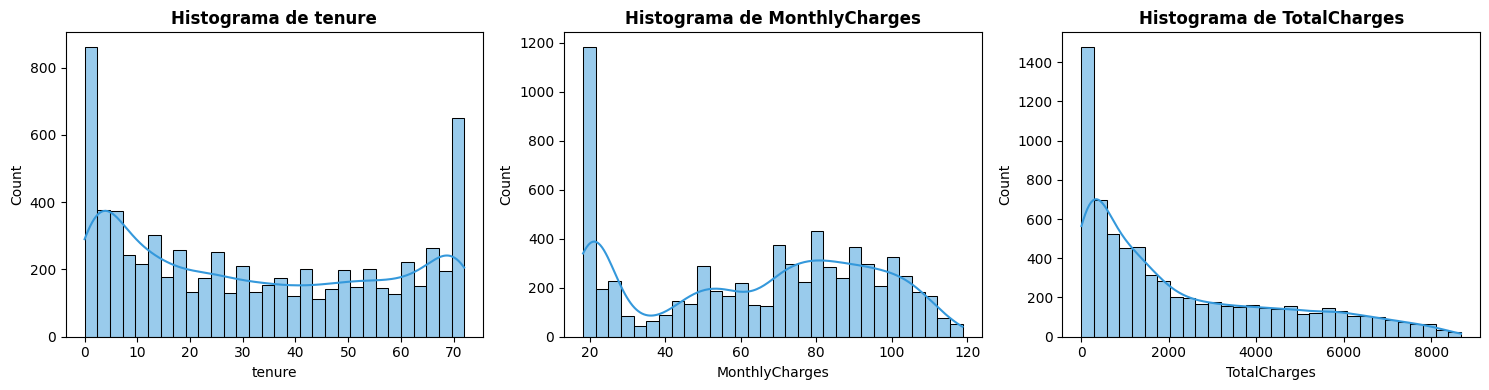

In [113]:
print("\nGenerando Boxplots...")
plot_histograms(df, num_vars)

Los histogramas permiten entender la forma de la distribución de cada variable. En tenure, se observa una distribución que no es uniforme: hay una mayor concentración tanto en valores bajos (clientes nuevos) como en valores altos (clientes antiguos), lo que sugiere una posible segmentación natural entre clientes recientes y fidelizados. En MonthlyCharges, la distribución presenta una ligera multimodalidad, lo que indica la existencia de distintos grupos de clientes asociados a diferentes paquetes de servicios (por ejemplo, planes básicos vs. premium). Finalmente, TotalCharges muestra una distribución fuertemente sesgada a la derecha, con una alta concentración de clientes en valores bajos y una cola larga hacia valores elevados; esto es consistente con su naturaleza acumulativa y su dependencia de tenure, evidenciando que pocos clientes concentran cargos totales muy altos. En conjunto, estas distribuciones sugieren que los datos no siguen una distribución normal, lo cual es relevante para la selección de modelos y técnicas de preprocesamiento.

## Preprocesamiento y detección de Data Leakage

Inicialmente se define una función para preparar la variable objetivo y el dataset, inicialmente se elimina la variable 'costumerID' pues es un identificador que no aporta información útil al modelo, seguido de esto se codifica la variable objetivo 'churn', de tal manera que quede como una variable númerica binaria, luego de esto se realiza la respectiva separación:

In [114]:
def preparar_objetivo() -> tuple[pd.DataFrame, pd.Series]:
    #Eliminar customerID 
    df.drop(columns=["customerID"], inplace=True)

    #Codificación de variable objetivo. Yes=1, No=0
    y = (df.pop("Churn") == "Yes").astype(int)
    X = df.copy()

    print(f"Dataset cargado: {X.shape[0]} observaciones, {X.shape[1]} predictoras")
    print(f"Distribución Churn: No={( y==0).sum()} | Yes={( y==1).sum()}\n")
    return X, y

Una vez hecho esto se definen en grupos las variables a utilizar para el modelo para facilitar el manejo y la aplicación del preprocesamiento. Para la codificación de variables categóricas se utilizará Ordinal Encoder, que asigna un número entero para cada categoría, esto es válido ya que los modelos basados en árboles como Random Forest, XGBoost, CatBoost y LightGBM realizan particiones del espacio de variables mediante puntos de corte numéricos, sin asumir relaciones de distancia o magnitud entre los valores, así el modelo evaluará distintos umbrales y encontrará las divisiones óptimas independientemente del orden asignado a las categorías. Además, este enfoque evita el aumento en la dimensionalidad que genera el One-Hot Encoding, lo que mejora la eficiencia computacional, especialmente durante procesos como la validación cruzada y la optimización de hiperparámetros.

Con todo claro, se construye el pipeline de pre-procesamiento, que incluye el escalado para las variables númericas y el codificado de las variables categóricas:

In [115]:
#Numéricas (escalar con StandardScaler)
NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges"]

#Categóricas binarias
BINARY_YN_FEATURES = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling",
]

#Categóricas 
CATEGORICAL_FEATURES = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]

ALL_CAT = BINARY_YN_FEATURES + CATEGORICAL_FEATURES

#Pipeline de pre-procesamiento con Column Transformer
def build_preprocessor() -> ColumnTransformer:
#StandardScaler para numéricas
#OrdinalEncoder para todas las categóricas (compatible con modelos basados en árboles)

    numeric_transformer = Pipeline([
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, NUMERIC_FEATURES),
            ("cat", categorical_transformer, ALL_CAT),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

Luego se procede a la validación cruzada, se empleó validación cruzada estratificada con cinco particiones usando el método StratifiedKFold con k=5, garantizando que cada fold mantenga la proporción original de clases (~74% No Churn - ~26% Churn), lo cual es importante debido al desbalance presente en el dataset. Como métrica principal de optimización se seleccionó el ROC-AUC, ya que evalúa la capacidad del modelo para discriminar entre ambas clases a lo largo de todos los umbrales de decisión posibles, siendo una métrica robusta e independiente del desbalance de clases.

In [116]:
#validación cruzada
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORER = make_scorer(roc_auc_score, needs_proba=True)  #métrica principal: ROC-AUC

Para cada modelo se construye un Pipeline de Scikit-learn que encadena secuencialmente el pre-procesador y el clasificador, garantizando que las transformaciones se ajusten exclusivamente sobre los datos de entrenamiento en cada fold y nunca sobre los de validación, evitando así data leakage. En el primer modelo que es Random-Forest, se utiliza **class_weight= "balanced"** que se usa para compensar el desbalance de las clases, en **rf_param_grid** se define el espacio de búsqueda sobre los hiperparámetros que controlan la complejidad del bosque: profundidad, tamaño mínimo de nodos, número de features por split, bootstrapping y criterio de división,luego este grid se entrega al GridSearchCV, que evaluará todas las combinaciones posibles usando la validación cruzada estratificada y la métrica ROC-AUC definidas globalmente, reentrenando al final el mejor estimador sobre la totalidad del conjunto de entrenamiento con el parámetro **refit=True**.

In [ ]:
#Pipelines de cada modelo y grids de hiperparámetros

preprocessor = build_preprocessor()

#RANDOM-FOREST
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",   #dataset desbalanceado ~26% churn
    )),
])

rf_param_grid = {
    "clf__max_depth":        [6, 10, 20],
    "clf__min_samples_split":[2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features":     ["sqrt", "log2", 0.5],
    "clf__bootstrap":        [True, False],
    "clf__criterion":        ["gini", "entropy"],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=CV,
    scoring=SCORER,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=True,
)

Para XGBoost se mantiene la misma estructura de Pipeline, con dos cambio: Primero, el manejo del desbalance de clases se realiza con scale_pos_weight, calculado como la razón entre observaciones negativas y positivas, lo que le indica al modelo que penalice tres veces más los errores sobre la clase minoritaria durante el entrenamiento. Segundo, se especifica **tree_method="hist"**, que construye los árboles mediante histogramas de gradiente, resultando significativamente más rápido que el método base, y además habilita de forma nativa la aceleración por GPU solo añadiendo **device="cuda"** sin cambios adicionales en el código. El grid de hiperparámetros se enfoca en controlar la regularización y el submuestreo: subsample y colsample_bytree reducen la varianza muestreando filas y columnas por árbol, gamma y min_child_weight regulan la complejidad de los splits exigiendo una ganancia mínima o un peso mínimo en los nodos hoja, y reg_alpha/reg_lambda aplican regularización L1 y L2 sobre los pesos de las hojas respectivamente. Finalmente, n_jobs=1 en el GridSearchCV evita la sobreasignación de hilos dado que XGBoost ya gestiona su propio paralelismo interno.

In [118]:
#XGBOOST  (GPU: device="cuda" si hay GPU disponible)

#scale_pos_weight se encarga del balanceo de las clases utilizando pesos

SCALE_POS = int(round((7043 * 0.74) / (7043 * 0.26)))  # ≈ 2.85 → ~3

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        scale_pos_weight=SCALE_POS,
        eval_metric="auc",
        use_label_encoder=False,
        random_state=42,
        #device="cuda",  #descomentar si GPU disponible (atento Sergio)
        tree_method="hist",  
        verbosity=0,
    )),
])

xgb_param_grid = {
    "clf__max_depth":        [4, 6, 8],
    "clf__subsample":        [0.7, 0.85, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__gamma":            [0, 0.1, 0.5],
    "clf__min_child_weight": [1, 3, 5],
    "clf__reg_alpha":        [0, 0.1, 1.0],
    "clf__reg_lambda":       [1.0, 1.5, 2.0],
}

xgb_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=CV,
    scoring=SCORER,
    n_jobs=1,           #XGBoost ya paraleliza internamente; n_jobs=1 evita conflictos
    refit=True,
    verbose=1,
    return_train_score=True,
)

CatBoost es el único modelo del proyecto que requiere un preprocesador diferenciado, esto es porque tiene su propio algoritmo de codificación de variables categóricas basado en ordered target statistics, lo que lo hace superior a cualquier codificación manual previa. Por esta razón, el ColumnTransformer aplica StandardScaler únicamente sobre las variables numéricas y deja pasar las categóricas sin transformación utilizando passthrough, conservando sus valores como strings. Tras el ColumnTransformer, las columnas quedan reordenadas, por lo que CAT_FEATURE_INDICES reconstruye explícitamente esas posiciones para informarle al clasificador qué columnas debe tratar como categóricas. El balanceo de clases se gestiona con auto_class_weights="Balanced", equivalente al class_weight="balanced" de Scikit-learn. En cuanto al grid, l2_leaf_reg controla la regularización L2 sobre los valores de las hojas, bagging_temperature regula la aleatoriedad del muestreo de observaciones, border_count determina la granularidad de la discretización de variables numéricas en histogramas, random_strength introduce ruido en los scores de los splits para reducir el sobreajuste, y one_hot_max_size define el umbral de cardinalidad por debajo del cual CatBoost aplica One-Hot Encoding en lugar de target encoding, siendo este último hiperparámetro especialmente relevante para las variables binarias del dataset.

In [119]:
#CATBOOST  (puede recibir las columnas categóricas sin codificarlas)

#CatBoost maneja categorías internamente asi que definimos un preprocesador diferente

cat_preprocessor_cb = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        #CatBoost recibe índices de columnas categóricas → aquí pasamos strings
        ("cat", "passthrough", ALL_CAT),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

#Índices de columnas categóricas DESPUÉS del ColumnTransformer
#num: 0,1,2  → cat empieza en 3
CAT_FEATURE_INDICES = list(range(len(NUMERIC_FEATURES), len(NUMERIC_FEATURES) + len(ALL_CAT)))

cb_pipeline = Pipeline([
    ("prep", cat_preprocessor_cb),
    ("clf", CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        cat_features=CAT_FEATURE_INDICES,
        auto_class_weights="Balanced",
        eval_metric="AUC",
        random_seed=42,
        verbose=0,
        #task_type="GPU",  #descomentar si hay GPU disponible
    )),
])

cb_param_grid = {
    "clf__depth":             [4, 6, 8],
    "clf__l2_leaf_reg":       [1, 3, 5, 10],
    "clf__bagging_temperature":[0.0, 0.5, 1.0],
    "clf__border_count":      [32, 64, 128],
    "clf__random_strength":   [1, 2, 5],
    "clf__one_hot_max_size":  [2, 5, 10],
    "clf__subsample":         [0.7, 0.85, 1.0],
}

cb_search = GridSearchCV(
    estimator=cb_pipeline,
    param_grid=cb_param_grid,
    cv=CV,
    scoring=SCORER,
    n_jobs=1,           #CatBoost paraleliza internamente también
    refit=True,
    verbose=1,
    return_train_score=True,
)

Por último está LightGBM su principal diferencia es que construye los árboles hoja por hoja (leaf-wise) en lugar de nivel por nivel (level-wise), lo que le permite encontrar particiones más precisas con menos iteraciones pero exige un control más cuidadoso de la complejidad. Esto se refleja en su grid: num_leaves es el hiperparámetro más crítico de LightGBM, ya que determina la complejidad máxima del árbol de forma más directa que max_depth, incluso max_depth=-1 elimina la restricción de profundidad y delega todo el control a num_leaves. Por otro lado, min_child_samples y min_child_weight actúan como regularizadores exigiendo un número mínimo de observaciones y suma de pesos en cada hoja, siendo el primero especialmente efectivo contra el sobreajuste en datasets pequeños. subsample y colsample_bytree submuestrean filas y columnas por árbol respectivamente, reg_alpha y reg_lambda aplican regularización L1 y L2, y max_bin controla la granularidad de los histogramas, de esta forma valores más altos aumentan la precisión de los splits a costa de mayor memoria y tiempo de cómputo. A diferencia de XGBoost y CatBoost, aquí n_jobs=-1 es seguro porque LightGBM respeta la paralelización externa del GridSearchCV sin conflictos de sobreasignación de hilos.

In [120]:
#LIGHTGBM  


lgbm_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1,
        # device="gpu",  # ← descomentar si GPU disponible
    )),
])

lgbm_param_grid = {
    "clf__num_leaves":        [31, 63, 127],
    "clf__max_depth":         [-1, 6, 10],
    "clf__min_child_samples": [10, 20, 50],
    "clf__min_child_weight":  [1e-3, 0.01, 0.1],
    "clf__subsample":         [0.7, 0.85, 1.0],
    "clf__colsample_bytree":  [0.6, 0.8, 1.0],
    "clf__reg_alpha":         [0, 0.1, 1.0],
    "clf__reg_lambda":        [0, 0.1, 1.0],
    "clf__max_bin":           [127, 255, 511],
}

lgbm_search = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=lgbm_param_grid,
    cv=CV,
    scoring=SCORER,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=True,
)


Una vez preparado y explicado cada modelo, se procede con el pipeline principal de entrenamiento.

In [121]:
#Entrenamiento

def evaluate_model(name: str, search: GridSearchCV, X_test, y_test) -> dict:
    #Imprime métricas del mejor estimador y devuelve un dict resumen
    best = search.best_estimator_
    y_pred = best.predict(X_test)
    y_prob = best.predict_proba(X_test)[:, 1]

    auc   = roc_auc_score(y_test, y_prob)
    f1    = f1_score(y_test, y_pred)
    cv_auc = search.best_score_

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Mejores hiperparámetros: {search.best_params_}")
    print(f"  CV ROC-AUC (train):      {cv_auc:.4f}")
    print(f"  Test ROC-AUC:            {auc:.4f}")
    print(f"  Test F1-Score:           {f1:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])}")

    return {
        "model": name,
        "best_params": search.best_params_,
        "cv_roc_auc": cv_auc,
        "test_roc_auc": auc,
        "test_f1": f1,
        "estimator": best,
    }


def run_pipeline():
    
    #Función principal que carga datos, entrena los 4 modelos y compara resultados
    
    #carga de los conjuntos
    X, y = preparar_objetivo()

    #Split estratificado 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}\n")

    #Ajuste de modelos
    MODELS = {
        "Random Forest": rf_search,
        "XGBoost":       xgb_search,
        "CatBoost":      cb_search,
        "LightGBM":      lgbm_search,
    }

    results = []
    for name, search in MODELS.items():
        print(f"\n>>> Entrenando {name}...")
        search.fit(X_train, y_train)
        res = evaluate_model(name, search, X_test, y_test)
        results.append(res)

    #Tabla comparativa
    summary = pd.DataFrame([
        {
            "Modelo":       r["model"],
            "CV ROC-AUC":   round(r["cv_roc_auc"], 4),
            "Test ROC-AUC": round(r["test_roc_auc"], 4),
            "Test F1":      round(r["test_f1"], 4),
        }
        for r in results
    ]).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)

    print("\n" + "="*60)
    print("  RESUMEN COMPARATIVO")
    print("="*60)
    print(summary.to_string(index=False))

    return results, summary


In [122]:
# Celda 1 — entrenamiento
results, summary = run_pipeline()

# Celda 2 — tabla comparativa de métricas
display(summary.drop(columns=["Mejores Params", "Estimador"]))

# Celda 3 — mejores hiperparámetros por modelo
display(summary[["Modelo", "Mejores Params"]])

Dataset cargado: 7043 observaciones, 19 predictoras
Distribución Churn: No=5174 | Yes=1869

Train: 5634 | Test: 1409


>>> Entrenando Random Forest...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

  Random Forest
  Mejores hiperparámetros: {'clf__bootstrap': True, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
  CV ROC-AUC (train):      nan
  Test ROC-AUC:            0.8242
  Test F1-Score:           0.5540

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


>>> Entrenando XGBoost...
Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


KeyboardInterrupt: 